In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [9]:
df=pd.read_csv("housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:
# 2. Separate features and target
X = df.drop("price", axis=1)
y = df["price"]

In [11]:
# 3. Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

In [12]:
# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# 5. Create Linear Regression model
model = LinearRegression()

# 6. Train the model
model.fit(X_train, y_train)

# 7. Predict house prices
y_pred = model.predict(X_test)

In [14]:

# 8. Calculate R² score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.6529242642153184


In [15]:
# 9. Display actual vs predicted prices
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Prices:")
print(results.head(10))



Actual vs Predicted Prices:
   Actual Price  Predicted Price
0       4060000     5.164654e+06
1       6650000     7.224722e+06
2       3710000     3.109863e+06
3       6440000     4.612075e+06
4       2800000     3.294646e+06
5       4900000     3.532275e+06
6       5250000     5.611775e+06
7       4543000     6.368146e+06
8       2450000     2.722857e+06
9       3353000     2.629406e+06


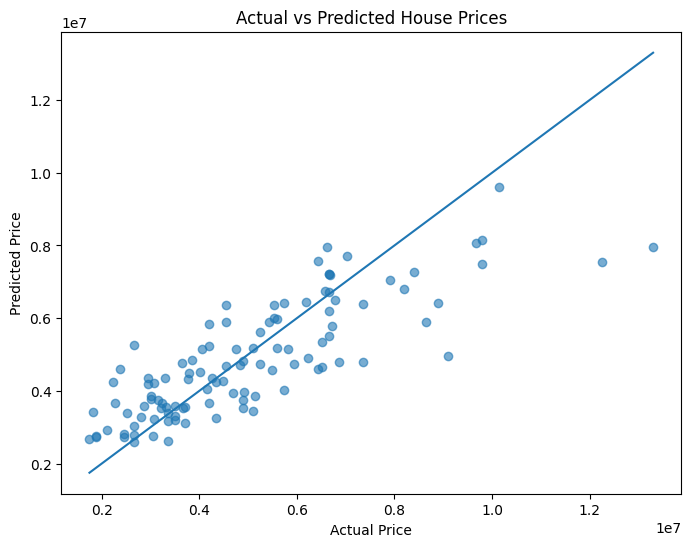

In [16]:
# 10. Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()